In [5]:
%pip install seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.manifold import TSNE

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
model = tf.keras.models.load_model("yawn_detection_model4.keras")

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 5,803,077 (22.14 MB)

 Trainable params: 1,690,497 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,380,996 (12.90 MB)

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_path = "yawn_dataset/train"
val_path = "yawn_dataset/val"

In [9]:
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())

print("Classes:", class_names)

Found 1233 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Classes: ['no_yawn', 'yawn']


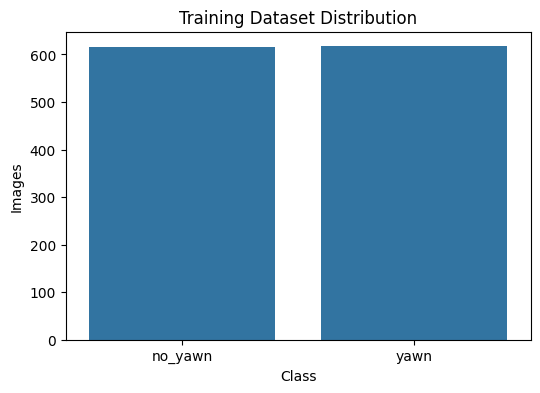

In [10]:
counts = {}

for cls in os.listdir(train_path):
    
    path = os.path.join(train_path, cls)
    
    if os.path.isdir(path):
        counts[cls] = len(os.listdir(path))

plt.figure(figsize=(6,4))

sns.barplot(
    x=list(counts.keys()),
    y=list(counts.values())
)

plt.title("Training Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Images")

plt.show()

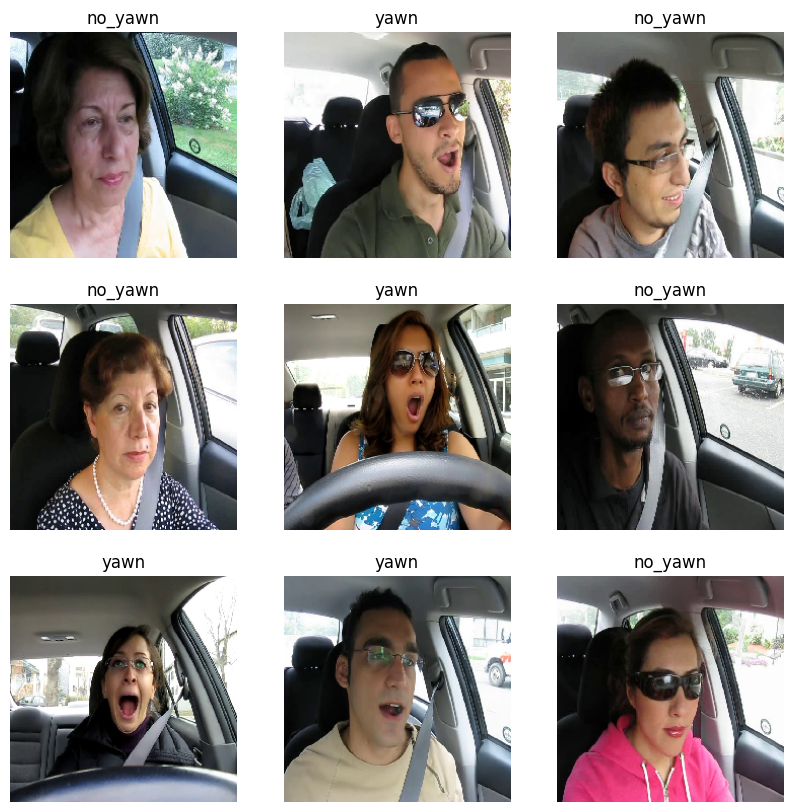

In [11]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)
    plt.imshow(images[i])

    label = class_names[int(labels[i])]
    
    plt.title(label)
    plt.axis("off")

plt.show()

In [12]:
predictions = model.predict(val_generator)

y_scores = predictions.ravel()
y_pred = (y_scores > 0.5).astype(int)

y_true = val_generator.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step


In [13]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

     no_yawn       0.99      0.92      0.95       109
        yawn       0.92      0.99      0.95       106

    accuracy                           0.95       215
   macro avg       0.96      0.95      0.95       215
weighted avg       0.96      0.95      0.95       215



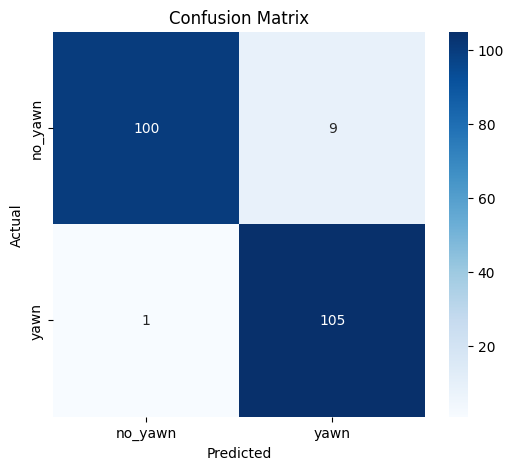

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

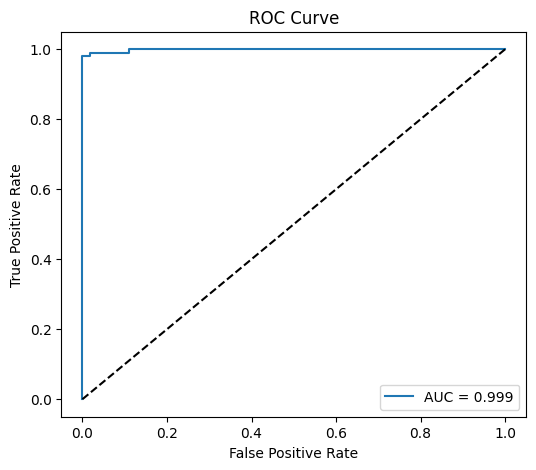

In [15]:
fpr, tpr, _ = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

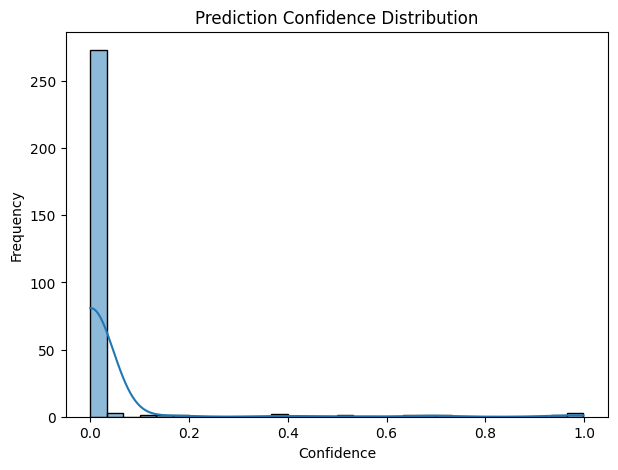

In [27]:
confidence = np.max(predictions, axis=1)

plt.figure(figsize=(7,5))

sns.histplot(confidence, bins=30, kde=True)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")

plt.show()

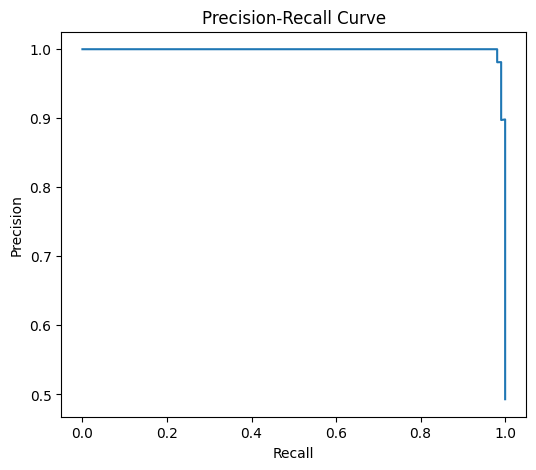

In [16]:
precision, recall, _ = precision_recall_curve(y_true, y_scores)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

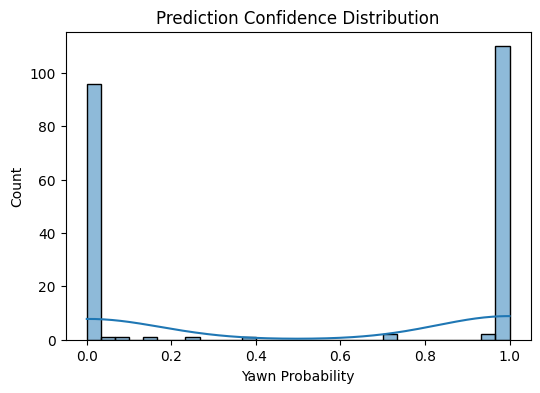

In [17]:
plt.figure(figsize=(6,4))

sns.histplot(y_scores, bins=30, kde=True)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Yawn Probability")

plt.show()

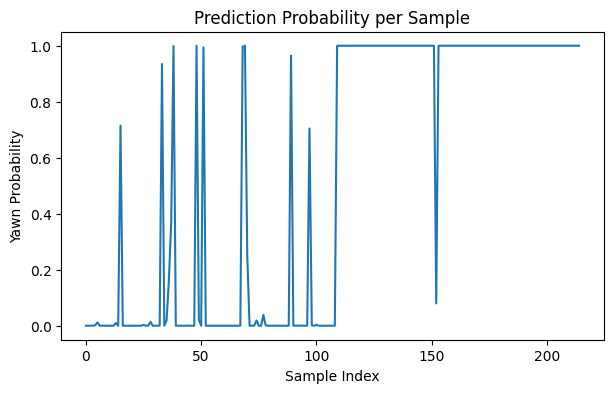

In [18]:
plt.figure(figsize=(7,4))

plt.plot(y_scores)

plt.title("Prediction Probability per Sample")
plt.xlabel("Sample Index")
plt.ylabel("Yawn Probability")

plt.show()

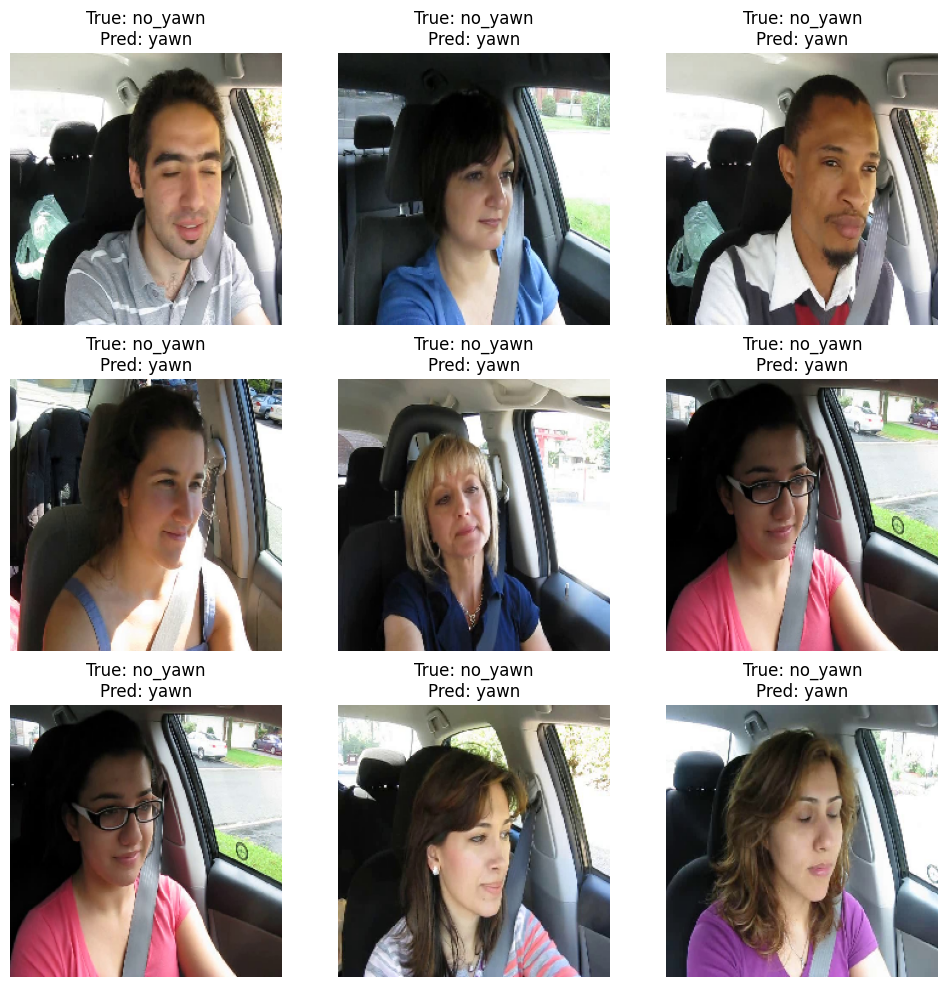

In [19]:
misclassified = np.where(y_pred != y_true)[0]

plt.figure(figsize=(12,12))

for i, idx in enumerate(misclassified[:9]):

    batch_index = idx // BATCH_SIZE
    image_index = idx % BATCH_SIZE

    batch_images, batch_labels = val_generator[batch_index]

    img = batch_images[image_index]

    plt.subplot(3,3,i+1)
    plt.imshow(img)

    plt.title(
        f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.show()

In [20]:
feature_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output
)

features = feature_model.predict(val_generator)

tsne = TSNE(n_components=2, random_state=42)

tsne_features = tsne.fit_transform(features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step


/opt/anaconda3/envs/yawning_model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/yawning_model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/yawning_model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/yawning_model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/yawning_model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/yawning_model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul

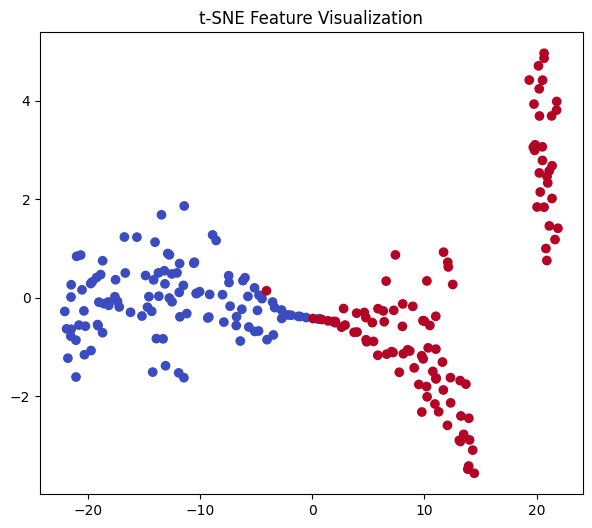

In [21]:
plt.figure(figsize=(7,6))

plt.scatter(
    tsne_features[:,0],
    tsne_features[:,1],
    c=y_true,
    cmap="coolwarm"
)

plt.title("t-SNE Feature Visualization")

plt.show()

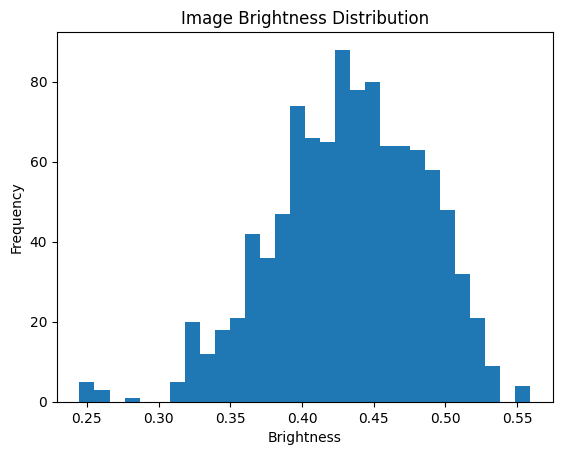

In [26]:
brightness = []

for batch in train_generator:

    imgs, _ = batch
    
    for img in imgs:
        brightness.append(img.mean())

    if len(brightness) > 1000:
        break

plt.hist(brightness, bins=30)

plt.title("Image Brightness Distribution")

plt.xlabel("Brightness")
plt.ylabel("Frequency")

plt.show()

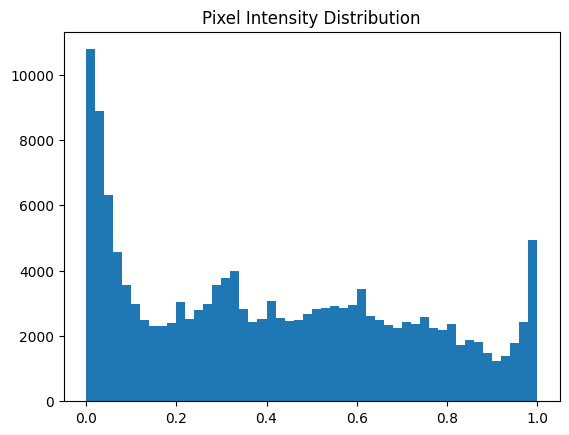

In [27]:
img = images[0]

plt.hist(img.ravel(), bins=50)

plt.title("Pixel Intensity Distribution")

plt.show()

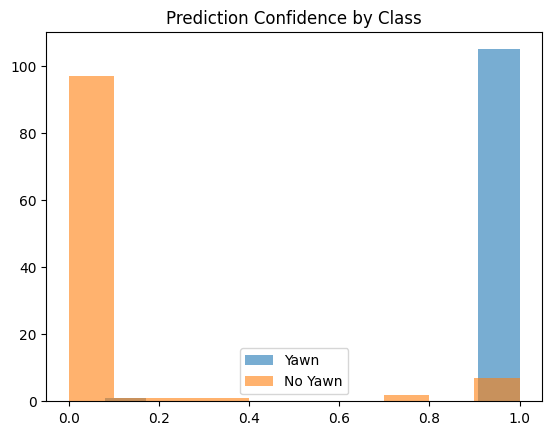

In [28]:
yawn_scores = y_scores[y_true == 1]
no_yawn_scores = y_scores[y_true == 0]

plt.hist(yawn_scores, alpha=0.6, label="Yawn")
plt.hist(no_yawn_scores, alpha=0.6, label="No Yawn")

plt.legend()

plt.title("Prediction Confidence by Class")

plt.show()

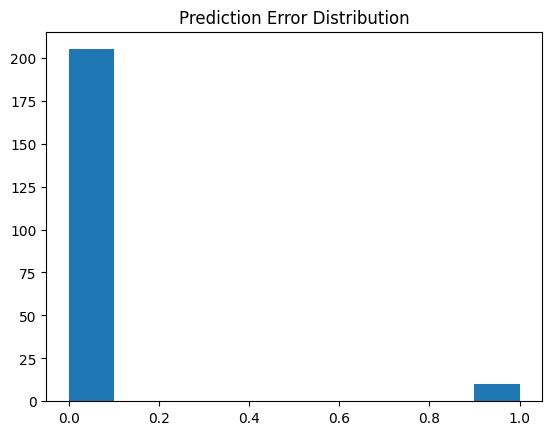

In [29]:
errors = np.abs(y_pred - y_true)

plt.hist(errors)

plt.title("Prediction Error Distribution")

plt.show()

In [30]:
layer_outputs = [layer.output for layer in model.layers[:8]]

activation_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=layer_outputs
)

activations = activation_model.predict(images[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


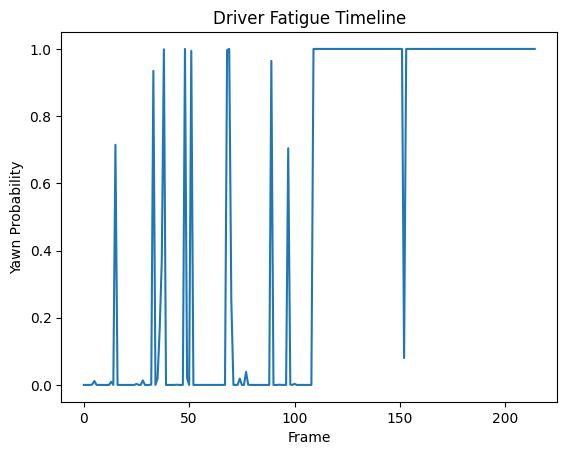

In [31]:
plt.plot(y_scores)

plt.title("Driver Fatigue Timeline")

plt.xlabel("Frame")
plt.ylabel("Yawn Probability")

plt.show()